# 04 · Reading decisions off the logits

*A row that ends at the decision position gives us a next-token distribution. This post is about turning it into a label: first tokens, quoted booleans, colliding labels, full strings and a 255-way trie, all read from the same batched calls.*

> **TL;DR**
> - Every decoder speaks one small language: rows appended to the prompt's KV state, and queries that ask for the log-probabilities of a few tokens at one position of one row. Four fields, including two with colliding labels, need four rows and one forward pass.
> - Most fields are decided by one token: renormalize the allowed first tokens and you have the decision. What falls outside is the candidate mass. On `secondary_anomaly` three quarters of the model's next token falls outside, most of it on the labels of a *different* field.
> - Booleans have two spellings. On the first field of `fintech_fraud` the model puts 82% on an opening quote; a decoder that reads only ` true` / ` false` answers "not fraud", while after the quote the model writes `true` with 84%. Summing both forms, `pcd` answers "fraud" at 0.82. Colliding labels are handled the same way: each branch is followed just deep enough, in the same row.
> - Exact full-string scoring almost never changes an answer, because after the identifying token the model nearly always spells the rest of the label as listed. With 255 labels that start with a numeric code, it is the other way round: four decoders give three different answers. Checked against brute-force enumeration on an oracle model, every decoder is exact to 1e-14.

Post [03](03_compiling_for_the_tokenizer.ipynb) ended with a compiled field: a **row** of tokens that ends at the decision position, and a token trie of **variants** after it, one per label and spelling. This post is about `decoding.py`, which reads a decision off the model for every field. We use Qwen2.5-1.5B-Instruct (4-bit MLX) and the presets from the earlier posts.

`engine.extract` hides the model calls. To look inside, we rebuild the two KV states the engine decides against: the prompt itself, for the schema's first field, and the prompt followed by the first field's answer line, for all the others (post [06](06_engine_and_benchmarks.ipynb) explains why the first field goes first).

In [1]:
from nbutils import *
import json
import math
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

from pcd import DecodeOptions, Engine, PromptFormat, Schema
from pcd.backends.base import Query
from pcd.compiler import compile_schema, encode_after
from pcd.decoding import FieldDecoder, decode_fields

environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
backend, tok = engine.backend, engine.tokenizer
VOCAB = tuple(range(tok.vocab_size))


_setups = {}


def setup(preset_name):
    """A preset, its compiled schema, the engine's answer, and the engine's two KV states."""
    if preset_name in _setups:
        return _setups[preset_name]
    p = load_preset(preset_name)
    cs = engine.compile(p["schema"])
    out = engine.extract(p["context"], p["schema"])
    ids = tok.encode(cs.prompt.render(p["context"].strip()))
    head = backend.prefill(cs.head_ids)
    p0 = backend.prefill(ids[len(cs.head_ids):], parent=head)                  # the prompt
    first = cs.schema.names[0]
    line = encode_after(tok, cs.prompt.tail, cs.answer_text({first: out.values[first]}))
    p1 = backend.prefill(line, parent=p0)                                        # + the first answer line
    _setups[preset_name] = p, cs, out, p0, p1
    return _setups[preset_name]


def next_token(prefix, row):
    """Log-probabilities of the whole vocabulary after ``row``."""
    return backend.score(prefix, [tuple(row)], [Query(0, len(row) - 1, VOCAB)])[0]


triage, tcs, tout, t0, t1 = setup("support_triage")
fraud, fcs, fout, f0, f1 = setup("fintech_fraud")
print("first fields:", tcs.schema.names[0], "|", fcs.schema.names[0])

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0
first fields: sentiment | is_fraudulent


## 1. The language the decoder speaks

A decoder never calls the model directly. It talks to the backend through one method:

In [2]:
show_source("backends/base.py", "``score(prefix, rows, queries)", "Must not modify ``prefix``")

# src/pcd/backends/base.py
11  ``score(prefix, rows, queries) -> list[np.ndarray]``
12      Treat every row as a continuation of ``prefix`` (all rows share the prefix's KV
13      state, broadcast to the batch). For each query ``(row, position, token_ids)`` return
14      the full-vocabulary log-softmax, at that position of that row, of the requested
15      token ids. ``position`` indexes into the row; the distribution at position ``p``
16      predicts the token at ``p + 1``. Must not modify ``prefix``.


A **row** is a short sequence of tokens that continues the prompt. A **query** asks for the log-probabilities of a few token ids at one position of one row. Each field has a `FieldDecoder`, a small state machine that says which rows and queries it needs, and `decode_fields` sends the requests of all pending fields to the backend in a single call. Here is what four triage fields ask for:

In [3]:
names = ["severity_tier", "sla_breach_risk", "target_resolution_hours", "assigned_agent_tier"]
for name in names:
    cf = tcs.fields[name]
    rows, queries = [], []
    FieldDecoder(cf, DecodeOptions()).request(rows, queries)
    print(f"{name}: {len(cf.labels)} labels → {len(rows)} row, {len(queries)} queries")
    for r in rows:
        print("   row      …" + "│".join(vis(p) for p in pieces(tok, r[-5:])))
    for q in queries:
        after = vis(tok.decode([rows[q.row][q.position]]))
        print(f"   after {after:>6}  compare {[tok.decode([t]) for t in q.tokens]}")
    print()

severity_tier: 4 labels → 1 row, 1 queries
   row      …":│·"│SE│V│_
   after      _  compare ['0', '1', '2', '3']

sla_breach_risk: 2 labels → 1 row, 2 queries
   row      …reach│_r│isk│":│·"
   after     ":  compare [' "', ' true', ' false']
   after     ·"  compare ['true', 'false']

target_resolution_hours: 4 labels → 1 row, 2 queries
   row      …_resolution│_hours│":│·"│1
   after     ·"  compare ['1', '2', '4']
   after      1  compare ['2', '_HOUR']

assigned_agent_tier: 4 labels → 1 row, 4 queries
   row      …":│·"│T│IER│_
   after     ·"  compare ['T', 'SE', 'DIRECT']
   after      T  compare ['IER']
   after    IER  compare ['_']
   after      _  compare ['1', '2']



Each field needs one row, but the rows say different things:

- `severity_tier`: the compiler already moved the shared `SE│V│_` into the row (post [03](03_compiling_for_the_tokenizer.ipynb) §5), so one query compares the four digits.
- `sla_breach_risk`: the row ends one token *past* the decision position, in ` "`. The first query compares ` true`, ` false` and ` "` after `":`; the second compares `true` and `false` after the quote. One row covers both ways of writing a boolean (section 3).
- `target_resolution_hours`: the row continues with `1`, so a second query can tell `1_HOUR` from `12_HOURS` (section 4).
- `assigned_agent_tier`: `TIER_1` and `TIER_2` share `T│IER│_`. The decoder queries those forced tokens too, so the probability of walking through them is counted, not assumed.

The rule that builds the rows fits in a few lines: collect every trie node the field needs a distribution at, and cover them with as few rows as possible, one per maximal path:

In [4]:
show_source("decoding.py", "# One row per maximal node path", "self.deep = self.deep")

# src/pcd/decoding.py
143          # One row per maximal node path; every node is read from a row that contains it.
144          paths: list[tuple[int, ...]] = []
145          for node in sorted(children, key=len, reverse=True):
146              if not any(p[: len(node)] == node for p in paths):
147                  paths.append(node)
148          row_of = {}
149          for p in paths:
150              row_of[p] = len(rows)
151              rows.append(base + p)
152          nodes = {}
153          for node, kids in children.items():
154              p = next(p for p in paths if p[: len(node)] == node)
155              toks = tuple(sorted(kids))
156              nodes[node] = (len(queries), toks)
157              queries.append(Query(row_of[p], len(base) - 1 + len(node), toks))
158          self.deep = self.deep or any(len(n) > 0 for n in children)


Now all four fields together:

In [5]:
passes = backend.forward_passes
res, rounds, n_rows = decode_fields(backend, t1, [tcs.fields[n] for n in names], DecodeOptions())
print(f"{rounds} round, {n_rows} rows, {backend.forward_passes - passes} forward pass")
md_table(["field", "value", "probability", "candidate mass", "method", "runner-up"],
         [[n, f"`{r.value}`", f"{r.probability:.3f}", f"{r.candidate_mass:.3f}", r.method,
           f"`{r.top[1][0]}` {r.top[1][1]:.3f}"] for n, r in res.items()])

1 round, 4 rows, 1 forward pass


| field | value | probability | candidate mass | method | runner-up |
|---|---|---|---|---|---|
| severity_tier | `SEV_0_CRITICAL` | 0.359 | 0.999 | first_token | `SEV_3_MINOR` 0.353 |
| sla_breach_risk | `True` | 0.708 | 0.996 | marginal | `False` 0.292 |
| target_resolution_hours | `12_HOURS` | 0.578 | 0.950 | marginal | `4_HOURS` 0.182 |
| assigned_agent_tier | `TIER_1` | 0.392 | 0.981 | marginal | `DIRECTOR` 0.280 |

`method` records how deep the decoder had to look: `first_token` when every label is identified at the decision position, `marginal` when it had to read further down the trie. Which reading a field gets is decided up front by its number of labels and `DecodeOptions.strategy`:

In [6]:
show_source("decoding.py", "def field_plan", "return (\"exact\"")

# src/pcd/decoding.py
79  def field_plan(cf: CompiledField, opts: DecodeOptions) -> tuple[str, int]:
80      """(mode, exact_below): mode is "marginal", "exact" or "trie"."""
81      k = len(cf.labels)
82      if opts.strategy == "greedy":
83          return "trie", 0
84      if k > opts.exact_max:
85          return "trie", opts.hybrid_exact_below
86      return ("exact" if opts.strategy == "exact" else "marginal"), 0


Up to `exact_max` (32) labels, one round of tree scoring decides the field (sections 2 to 5). Above that, a greedy walk down the trie, which we meet in section 6.

## 2. One token, one decision

For most fields one query at the decision position is the whole story. Let us look at everything the model wants to write there, not just the allowed tokens. Two fields, one from each preset:

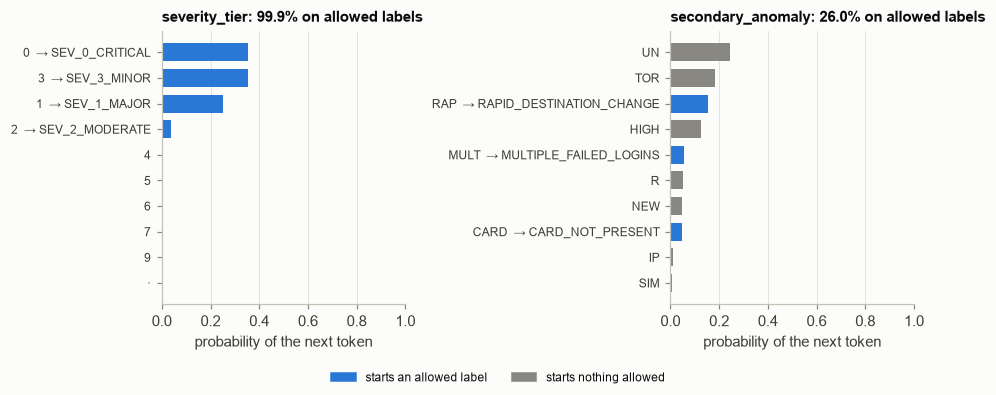

In [7]:
def top_tokens(cs, prefix, name, k=10):
    cf = cs.fields[name]
    lp = next_token(prefix, cf.prefix)
    firsts = {}
    for v in cf.canonical_variants():
        firsts.setdefault(v.seq[0], []).append(cf.labels[v.label])
    top = [int(t) for t in np.argsort(-lp)[:k]]
    mass = float(np.exp(lp[list(firsts)]).sum())
    return lp, firsts, top, mass


fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6))
for ax, (cs, prefix, name) in zip(axes, [(tcs, t1, "severity_tier"), (fcs, f1, "secondary_anomaly")]):
    lp, firsts, top, mass = top_tokens(cs, prefix, name)
    probs = [float(np.exp(lp[t])) for t in top]
    labels = [f"{vis(tok.decode([t]))}" + (f"  → {firsts[t][0]}" if t in firsts else "") for t in top]
    ax.barh(range(len(top)), probs, color=[SERIES[0] if t in firsts else MUTED for t in top], height=0.7)
    ax.set_yticks(range(len(top)), labels, fontsize=8)
    ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, 1)
    ax.set_xlabel("probability of the next token")
    ax.set_title(f"{name}: {mass:.1%} on allowed labels", fontsize=10)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (SERIES[0], MUTED)]
fig.legend(handles, ["starts an allowed label", "starts nothing allowed"], loc="lower center", ncol=2, fontsize=8)
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()

On the left, the model's next token is almost always one of the four digits, and the decision is a question of which. `SEV_0` and `SEV_3` are nearly tied, which we already saw in post [01](01_why_parallel_decoding.ipynb).

On the right, most of the probability goes to tokens that no allowed label starts with. They are not random:

In [8]:
lp, firsts, top, mass = top_tokens(fcs, f1, "secondary_anomaly")
primary = {v.seq[0]: fcs.fields["primary_anomaly"].labels[v.label] for v in fcs.fields["primary_anomaly"].canonical_variants()}
md_table(["token", "probability", "allowed here?", "a `primary_anomaly` label starting with it"],
         [[f"`{vis(tok.decode([t]))}`", f"{np.exp(lp[t]):.3f}", "yes" if t in firsts else "no", primary.get(t, "")] for t in top[:8]])
print(f"next token starts an allowed label: {mass:.2f}; starts a primary_anomaly label: {float(np.exp(lp[list(primary)]).sum()):.2f}")

| token | probability | allowed here? | a `primary_anomaly` label starting with it |
|---|---|---|---|
| `UN` | 0.245 | no | UNUSUAL_VELOCITY |
| `TOR` | 0.185 | no | TOR_EXIT_NODE |
| `RAP` | 0.156 | yes |  |
| `HIGH` | 0.125 | no | HIGH_VALUE_TRANSFER |
| `MULT` | 0.055 | yes |  |
| `R` | 0.053 | no |  |
| `NEW` | 0.049 | no | NEW_DEVICE |
| `CARD` | 0.047 | yes |  |

next token starts an allowed label: 0.26; starts a primary_anomaly label: 0.61


The model wants to write `UNUSUAL_VELOCITY`, `TOR_EXIT_NODE` or `HIGH_VALUE_TRANSFER`: labels of `primary_anomaly`, the field above it, which this field does not allow. That is what **candidate mass** measures. The decoder renormalizes over the allowed first tokens:

In [9]:
allowed = sorted(firsts, key=lambda t: -lp[t])
raw = np.exp(lp[allowed])
for t, p in zip(allowed, raw):
    print(f"{firsts[t][0]:26} raw {p:.3f}   renormalized {p / raw.sum():.3f}")
r = fout.fields["secondary_anomaly"]
print(f"\ncandidate mass {raw.sum():.3f}; the engine reported {r.value} at {r.probability:.3f} with mass {r.candidate_mass:.3f}")

RAPID_DESTINATION_CHANGE   raw 0.156   renormalized 0.597
MULTIPLE_FAILED_LOGINS     raw 0.055   renormalized 0.213
CARD_NOT_PRESENT           raw 0.047   renormalized 0.179
NONE                       raw 0.003   renormalized 0.010

candidate mass 0.260; the engine reported RAPID_DESTINATION_CHANGE at 0.597 with mass 0.260


Renormalized, `RAPID_DESTINATION_CHANGE` wins at about 0.6, a confident-looking number built on a quarter of the model's belief. Both numbers are reported for every field for exactly this reason: `probability` says how the model splits its belief among the options you allowed, `candidate_mass` says how much it believes any of them. (Post [02](02_schemas_and_prompts.ipynb) §5 shows what happens to the mass when the prompt does not list the allowed values at all.)

## 3. Two ways to write `true`

In post [03](03_compiling_for_the_tokenizer.ipynb) §1, about a tenth of the probability after `":` on triage booleans went to ` "`, the opening quote of a string. On the first field of `fintech_fraud` it is far more:

In [10]:
cf = fcs.fields["is_fraudulent"]
lp = next_token(f0, cf.prefix)
print('after "is_fraudulent":')
for t in np.argsort(-lp)[:5]:
    print(f"   {vis(tok.decode([int(t)])):>8}  {np.exp(lp[t]):.3f}")
QUOTE = tok.encode(' "')[0]
lq = next_token(f0, cf.prefix + (QUOTE,))
print('after "is_fraudulent": "')
for t in np.argsort(-lq)[:5]:
    print(f"   {vis(tok.decode([int(t)])):>8}  {np.exp(lq[t]):.3f}")

after "is_fraudulent":
         ·"  0.815
     ·false  0.100
      ·true  0.083
      ·null  0.001
      ·"",⏎  0.000
after "is_fraudulent": "
       true  0.844
      false  0.084
       TRUE  0.043
      FALSE  0.020
        YES  0.003


The model puts 82% on the quote and splits the rest almost evenly between ` false` and ` true`. After the quote it clearly prefers `true`. A decoder that only reads the unquoted forms sees 0.100 against 0.083 and answers "not fraud" for a transaction from a Tor exit node that bypassed 2FA.

`pcd` treats `true` and `"true"` as two variants of the same label (post [03](03_compiling_for_the_tokenizer.ipynb) §6) and sums them. With the numbers above:

In [11]:
T, F = tok.encode(" true")[0], tok.encode(" false")[0]
QT, QF = tok.encode('"true')[1], tok.encode('"false')[1]
p = {k: float(np.exp(v)) for k, v in [("q", lp[QUOTE]), ("t", lp[T]), ("f", lp[F]), ("qt", lq[QT]), ("qf", lq[QF])]}
bare = p["t"] / (p["t"] + p["f"])
yes, no = p["t"] + p["q"] * p["qt"], p["f"] + p["q"] * p["qf"]
print(f"bare forms only : P(true) = {p['t']:.3f} / ({p['t']:.3f} + {p['f']:.3f}) = {bare:.3f}   → {bare > 0.5}")
print(f"both forms      : P(true) ∝ {p['t']:.3f} + {p['q']:.3f}·{p['qt']:.3f} = {yes:.3f},  P(false) ∝ {p['f']:.3f} + {p['q']:.3f}·{p['qf']:.3f} = {no:.3f}"
      f"   → {yes / (yes + no):.3f}")
r = fout.fields["is_fraudulent"]
print(f"engine          : {r.value} at {r.probability:.3f}, candidate mass {r.candidate_mass:.3f}, method {r.method}")

bare forms only : P(true) = 0.083 / (0.083 + 0.100) = 0.453   → False
both forms      : P(true) ∝ 0.083 + 0.815·0.844 = 0.771,  P(false) ∝ 0.100 + 0.815·0.084 = 0.169   → 0.821
engine          : True at 0.821, candidate mass 0.940, method marginal


The engine's answer is this arithmetic, read from the one row of section 1. The candidate mass (0.94) counts both spellings; most of the missing 6% is the quote followed by `TRUE` or `FALSE` in capitals, spellings the schema does not accept.

Why does the first field get quoted so much more than the triage booleans? Because of what comes before it. Here is the probability of ` "` for every boolean in every preset, split by whether the field is decided on the bare prompt or after the first field's answer line:

In [12]:
def quote_mass(cs, prefix, cf):
    return float(np.exp(backend.score(prefix, [cf.prefix], [Query(0, len(cf.prefix) - 1, (QUOTE,))])[0][0]))


rows = []
for name in PRESET_NAMES:
    p, cs, out, p0, p1 = setup(name)
    first = cs.schema.names[0]
    later = [quote_mass(cs, p1, cf) for n, cf in cs.fields.items() if cf.field.type == "boolean" and n != first]
    first_q = quote_mass(cs, p0, cs.fields[first]) if cs.fields[first].field.type == "boolean" else None
    rows.append([name, f"`{cs.answer_text({first: out.values[first]}).strip()}`",
                 "—" if first_q is None else f"{first_q:.3f}", len(later), f"{np.median(later):.4f}", f"{max(later):.3f}"])
md_table(["preset", "first answer line written into the prompt", 'P(` "`) on the first field',
          "later booleans", 'median P(` "`)', "max"], rows)

| preset | first answer line written into the prompt | P(` "`) on the first field | later booleans | median P(` "`) | max |
|---|---|---|---|---|---|
| support_triage | `"sentiment": "NEGATIVE",` | — | 15 | 0.1174 | 0.423 |
| fintech_fraud | `"is_fraudulent": true,` | 0.815 | 16 | 0.0001 | 0.002 |
| code_security | `"is_vulnerability": true,` | 0.868 | 13 | 0.0011 | 0.004 |
| high_cardinality_255 | `"customs_category": "CAT_098_Satellite_Telemetry_Transceivers",` | — | 2 | 0.0092 | 0.016 |

On the bare prompt, right after `{`, nothing in the answer shows how this JSON writes booleans, and on `fintech_fraud` and `code_security` the model guesses a string. Once a line like `"is_fraudulent": true,` is in the prompt, the model copies it and the quote all but disappears. After a line with a quoted string it depends on the schema: a median of about 12% on the triage booleans, about 1% on the customs preset's two.

What if we did not score the quoted forms? `PromptFormat(quoted_booleans=False)` compiles booleans with the bare spelling only. We run it with the engine's default (first field decided on its own and written into the prompt) and without:

In [13]:
bare_engine = Engine(backend, prompt_format=PromptFormat(quoted_booleans=False))
for anchor in (True, False):
    a = engine.extract(fraud["context"], fraud["schema"], anchor_first=anchor)
    b = bare_engine.extract(fraud["context"], fraud["schema"], anchor_first=anchor)
    diff = [k for k in a.values if a.values[k] != b.values[k]]
    fb = b.fields["is_fraudulent"]
    print(f"anchor_first={anchor!s:5}  is_fraudulent: {a.values['is_fraudulent']} → {fb.value} "
          f"(p {fb.probability:.2f}, mass {fb.candidate_mass:.2f})   fields that change: {len(diff)} of {len(a.values)}")

anchor_first=True   is_fraudulent: True → False (p 0.55, mass 0.18)   fields that change: 24 of 28
anchor_first=False  is_fraudulent: True → False (p 0.55, mass 0.18)   fields that change: 1 of 28


Without the quoted forms, `is_fraudulent` becomes `False` at 0.55, from a candidate mass of 0.18. Decided in isolation, that is the only field that changes. With the engine's default, the wrong answer is written into the prompt as `"is_fraudulent": false,` before the other 27 fields are decided, and the model follows it: 24 of the 28 fields change. The first field's answer is worth getting right, and one missing spelling is enough to get it wrong.

## 4. Collisions: follow each branch just far enough

`target_resolution_hours` has four labels but only three first tokens: `1_HOUR` and `12_HOURS` both start with `1`. A first-token decoder could only report their sum. The marginal decoder follows the `1` branch one token further, in the same row, and multiplies. To check it, we score every label by hand, one row per label, token by token up to the identifying one:

In [14]:
def by_hand(cs, prefix, name):
    """Each label's log-probability up to its identifying token, one row per label."""
    cf = cs.fields[name]
    scores = {}
    for v in cf.canonical_variants():
        seq = v.seq[: v.ident + 1]
        steps = backend.score(prefix, [cf.prefix + seq], [Query(0, len(cf.prefix) - 1 + j, (seq[j],)) for j in range(len(seq))])
        steps = [float(s[0]) for s in steps]
        scores[cf.labels[v.label]] = sum(steps)
        print(f"   {cf.labels[v.label]:12} " + "  ".join(f"{vis(tok.decode([t]))}:{s:+.3f}" for t, s in zip(seq, steps)))
    s = np.array(list(scores.values()))
    return dict(zip(scores, np.exp(s - np.logaddexp.reduce(s)))), float(np.exp(s).sum())


for name in ["target_resolution_hours", "assigned_agent_tier"]:
    print(f"{name} (log-probability of each token):")
    hand, hand_mass = by_hand(tcs, t1, name)
    r = decode_fields(backend, t1, [tcs.fields[name]], DecodeOptions())[0][name]
    dec = dict(r.top)
    print(f"   decoder: {r.value} {r.probability:.4f} ({r.method}); by hand: {max(hand, key=hand.get)} {max(hand.values()):.4f}; "
          f"largest difference {max(abs(dec[k] - hand[k]) for k in hand):.1e}; mass {r.candidate_mass:.4f} vs {hand_mass:.4f}\n")

target_resolution_hours (log-probability of each token):
   1_HOUR       1:-0.346  _HOUR:-1.621
   4_HOURS      4:-1.769
   12_HOURS     1:-0.346  2:-0.246
   24_HOURS     2:-2.441
   decoder: 12_HOURS 0.5781 (marginal); by hand: 12_HOURS 0.5821; largest difference 4.0e-03; mass 0.9499 vs 0.9510

assigned_agent_tier (log-probability of each token):
   TIER_1       T:-0.809  IER:-0.000  _:+0.000  1:-0.145
   TIER_2       T:-0.809  IER:-0.000  _:+0.000  2:-2.005
   SENIOR_SRE   SE:-1.340
   DIRECTOR     DIRECT:-1.294
   decoder: TIER_1 0.3924 (marginal); by hand: TIER_1 0.3924; largest difference 5.6e-17; mass 0.9808 vs 0.9808



The branch structure is visible in the numbers. For `target_resolution_hours`, `1` has by far the best first token (-0.35 against -1.77 for `4`), and one token later `2` beats `_HOUR` (-0.25 against -1.62), so `12_HOURS` wins. A first-token decoder could only have reported `1_HOUR` and `12_HOURS` together. For `assigned_agent_tier`, `IER` and `_` are forced (their log-probabilities round to zero), and `1` beats `2` by a wide margin.

For `assigned_agent_tier` the decoder and the hand computation agree to 1e-16. For `target_resolution_hours` they differ in the third decimal. That is not the decoder: the hand-built rows have different lengths from the decoder's row, and the GPU computes a slightly different float result for a differently shaped batch. Post [05](05_backends.ipynb) measures that noise; section 7 below removes it with a model whose probabilities are exact.

## 5. Exact scoring: let the rest of the label speak

The marginal decoder stops at the identifying token. Everything after it is ignored: `SEV_0` decides `SEV_0_CRITICAL` whatever the model thinks of `_CRITICAL`. `DecodeOptions(strategy="exact")` scores every variant's whole line instead, up to and including the closing `",⏎` (post [03](03_compiling_for_the_tokenizer.ipynb) §3 shows why that closing token has to be the one the model really writes).

How much can the rest of a label change? For every label of the three 28-field presets we compute its **tail**: the log-probability of the tokens after the identifying one.

In [15]:
tails = []
for name in ["support_triage", "fintech_fraud", "code_security"]:
    p, cs, out, p0, p1 = setup(name)
    for fname, cf in cs.fields.items():
        prefix = p0 if fname == cs.schema.names[0] else p1
        vs = cf.canonical_variants()
        qs = [(i, Query(i, len(cf.prefix) - 1 + j, (v.seq[j],))) for i, v in enumerate(vs) for j in range(v.ident + 1, len(v.seq))]
        lps = backend.score(prefix, [cf.prefix + v.seq for v in vs], [q for _, q in qs])
        tail = [0.0] * len(vs)
        for (i, _), x in zip(qs, lps):
            tail[i] += float(x[0])
        tails += [(t, name, fname, cf.labels[v.label], v) for v, t in zip(vs, tail)]
tails.sort(key=lambda x: x[0])
ts = np.array([t for t, *_ in tails])
print(f"{len(ts)} labels: median tail {np.median(ts):+.4f} nats; {np.mean(ts > -0.01):.0%} above -0.01, {np.mean(ts > -0.1):.0%} above -0.1")
md_table(["tail (nats)", "preset", "field", "label", "tokens after the identifying one"],
         [[f"{t:+.2f}", n, f, f"`{lab}`", "`" + "│".join(vis(x) for x in pieces(tok, v.seq[v.ident + 1:])) + "`"]
          for t, n, f, lab, v in tails[:5]])
for t, n, f, lab, v in tails[:2]:
    p, cs, out, p0, p1 = setup(n)
    cf = cs.fields[f]
    prefix = p0 if f == cs.schema.names[0] else p1
    row = cf.prefix + v.seq
    lp = backend.score(prefix, [row], [Query(0, len(cf.prefix) - 1 + j, VOCAB) for j in range(v.ident + 1, len(v.seq))])
    print(f"{lab}:")
    for j, x in zip(range(v.ident + 1, len(v.seq)), lp):
        best = int(np.argmax(x))
        print(f"   after {vis(''.join(pieces(tok, v.seq[:j]))):>14}  {vis(tok.decode([v.seq[j]])):>10} {x[v.seq[j]]:+.2f}"
              f"   (model's favorite: {vis(tok.decode([best]))} {x[best]:+.2f})")

241 labels: median tail -0.0022 nats; 87% above -0.01, 98% above -0.1


| tail (nats) | preset | field | label | tokens after the identifying one |
|---|---|---|---|---|
| -3.78 | code_security | target_environment | `PRODUCTION_CLUSTER` | `DUCTION│_CLUSTER│",⏎` |
| -1.21 | code_security | primary_cwe | `CWE_20_IMPROPER_INPUT` | `0│_IM│PRO│PER│_INPUT│",⏎` |
| -0.24 | code_security | secondary_cwe | `CWE_200_INFO_EXPOSURE` | `0│0│_INFO│_EX│POS│URE│",⏎` |
| -0.12 | code_security | assigned_team | `CORE_BACKEND` | `_BACKEND│",⏎` |
| -0.10 | fintech_fraud | recommended_action | `BLOCK_TRANSACTION` | `_TRANSACTION│",⏎` |

PRODUCTION_CLUSTER:
   after            PRO     DUCTION -0.00   (model's favorite: DUCTION -0.00)
   after     PRODUCTION    _CLUSTER -3.76   (model's favorite: ",⏎ -0.09)
   after PRODUCTION_CLUSTER         ",⏎ -0.00   (model's favorite: ",⏎ -0.00)
CWE_20_IMPROPER_INPUT:
   after              2           0 -0.01   (model's favorite: 0 -0.01)
   after             20         _IM -1.20   (model's favorite: 0 -0.38)
   after          20_IM         PRO -0.00   (model's favorite: PRO -0.00)
   after       20_IMPRO         PER -0.00   (model's favorite: PER -0.00)
   after    20_IMPROPER      _INPUT -0.00   (model's favorite: _INPUT -0.00)
   after 20_IMPROPER_INPUT         ",⏎ -0.00   (model's favorite: ",⏎ -0.00)


Nearly always, once the model has committed to the identifying token, it spells the rest of the label exactly as the catalog lists it: 87% of the tails are within 0.01 nats of certainty. The exceptions are labels that surprise the model halfway. After `PRODUCTION` it wants to close the string, as if the label were just `PRODUCTION`. After `CWE_20` it wants another `0`, as in `CWE_200_INFO_EXPOSURE`, a label of the neighboring field `secondary_cwe`. Those are the only places where exact scoring can move a decision.

So does it? We run both strategies on the same KV states, so the only difference is the scoring:

In [16]:
rows = []
for name in PRESET_NAMES:
    p, cs, out, p0, p1 = setup(name)
    first, rest = cs.schema.names[0], [cs.fields[n] for n in cs.schema.names[1:]]
    run = {}
    for strategy in ("auto", "exact"):
        opts = DecodeOptions(strategy=strategy)
        t, passes = time.perf_counter(), backend.forward_passes
        r0, _, n0 = decode_fields(backend, p0, [cs.fields[first]], opts)
        r1, _, n1 = decode_fields(backend, p1, rest, opts)
        run[strategy] = ({**r0, **r1}, n0 + n1, backend.forward_passes - passes, (time.perf_counter() - t) * 1e3)
    (a, ra, pa, ma), (e, re_, pe, me) = run["auto"], run["exact"]
    diff = [f"`{k}`: {a[k].value} {a[k].probability:.3f} → {e[k].value} {e[k].probability:.3f}" for k in a if a[k].value != e[k].value]
    rows.append([name, f"{ra} → {re_}", f"{pa} → {pe}", f"{me / ma:.1f}×", "; ".join(diff) or "none"])
md_table(["preset", "rows", "forward passes", "decode time", "decisions that change"], rows)

| preset | rows | forward passes | decode time | decisions that change |
|---|---|---|---|---|
| support_triage | 28 → 114 | 2 → 3 | 3.0× | `sentiment`: NEGATIVE 0.395 → VERY_NEGATIVE 0.396 |
| fintech_fraud | 28 → 110 | 2 → 3 | 3.3× | none |
| code_security | 28 → 109 | 2 → 3 | 4.5× | none |
| high_cardinality_255 | 15 → 23 | 4 → 4 | 0.6× | none |

One decision in 88 changes, and it is a near-tie: `sentiment`, where the marginal picks `NEGATIVE` at 0.395 and exact scoring picks `VERY_NEGATIVE` at 0.396, so the tails break the tie. For that, exact scoring reads about four times as many rows. On `high_cardinality_255` both strategies use the same trie walk for the big field (section 6), so there is little to compare.

The engine end to end is a different story, because `sentiment` is the triage schema's first field and its answer line is written into the prompt before the others are decided:

In [17]:
e_out = engine.extract(triage["context"], triage["schema"], strategy="exact")
print([f"{k}: {tout.values[k]} → {e_out.values[k]}" for k in tout.values if tout.values[k] != e_out.values[k]])

['sentiment: NEGATIVE → VERY_NEGATIVE', 'severity_tier: SEV_0_CRITICAL → SEV_3_MINOR', 'assigned_agent_tier: TIER_1 → DIRECTOR']


Three fields change: `sentiment` itself, and `severity_tier` and `assigned_agent_tier`, which are decided after it and now read `VERY_NEGATIVE` in the line above. On the same prompt, exact scoring left both of them alone. Exact scoring is the right tool when labels share long prefixes and differ late, or when you want the model's opinion of the whole label; on these schemas, `auto` gives the same answers for a quarter of the rows.

## 6. 255 labels: walking the trie

Above `exact_max` labels, reading every variant in one round gets expensive, and the decoder switches to a **greedy trie walk**: at each branch, restrict the next token to the ones that keep some label alive, renormalize, follow the best, and repeat. Tokens that every surviving label agrees on are appended without asking the model.

The `high_cardinality_255` preset asks for a customs category out of 255 labels of the form `CAT_095_Aerospace_Titanium_Fasteners_&_Bolts`. Post [03](03_compiling_for_the_tokenizer.ipynb) §6 showed its trie with Qwen's tokenizer: the row ends at `CAT_`, then three levels of digits. Here is the model's view at the decision position:

In [18]:
hc, hcs, hout, h0, h1 = setup("high_cardinality_255")
big = hcs.fields["customs_category"]
names_of = {}
for c in big.labels:
    names_of.setdefault(c.split("_", 2)[2], []).append(c)
print(f"{len(big.labels)} labels, {len(names_of)} distinct names; e.g. {names_of['Aerospace_Titanium_Fasteners_&_Bolts']}")
print(f"prompt: {len(tok.encode(hcs.prompt.render(hc['context'])))} tokens, of which the catalog head is {len(hcs.head_ids)}")
lp = next_token(h0, big.prefix)
print("after …" + "│".join(vis(x) for x in pieces(tok, big.prefix[-3:])) + ":  " +
      ", ".join(f"{vis(tok.decode([int(t)]))} {np.exp(lp[t]):.3f}" for t in np.argsort(-lp)[:4]))

255 labels, 100 distinct names; e.g. ['CAT_095_Aerospace_Titanium_Fasteners_&_Bolts', 'CAT_195_Aerospace_Titanium_Fasteners_&_Bolts']
prompt: 4624 tokens, of which the catalog head is 4461
after …·"│CAT│_:  0 0.520, 1 0.466, 2 0.006, 8 0.004


The preset is a stress test: 100 category names, each listed two or three times under different codes, so the item described in the invoice (titanium fasteners for turbine rotors) is `CAT_095` or `CAT_195`. And the first thing the model must decide is a digit: `0` or `1`, almost a coin flip, with no meaning attached to either.

To see what the decoder asks for, we wrap `backend.score` and record every call:

In [19]:
class Trace:
    """Record every backend.score call made inside the block."""

    def __enter__(self):
        self.calls = []

        def score(prefix, rows, queries):
            self.calls.append((rows, queries))
            return type(backend).score(backend, prefix, rows, queries)

        backend.score = score
        return self

    def __exit__(self, *exc):
        del backend.score

    def show(self, row_start):
        for i, (rows, queries) in enumerate(self.calls, 1):
            opts = [len(q.tokens) for q in queries]
            print(f"   round {i}: {len(rows)} row(s), {len(queries)} queries (options per query: "
                  f"{opts[:6]}{' …' if len(opts) > 6 else ''})")
            for r in rows[:3]:
                print("      row …" + "".join(pieces(tok, r[row_start:])))
            if len(rows) > 3:
                print(f"      … and {len(rows) - 3} more")


for label, opts in [("greedy", DecodeOptions(strategy="greedy")), ("auto (hybrid)", DecodeOptions())]:
    with Trace() as tr:
        r = decode_fields(backend, h0, [big], opts)[0]["customs_category"]
    print(f"{label}: {r.value} at {r.probability:.3f} ({r.method}); runner-up {r.top[1][0]} at {r.top[1][1]:.3f}")
    tr.show(len(big.prefix) - 2)
    print()

greedy: CAT_099_Semiconductor_Lithography_Masks at 0.237 (trie); runner-up CAT_096_Precision_CNC_Rotary_Turbines at 0.037
   round 1: 1 row(s), 1 queries (options per query: [3])
      row …CAT_
   round 2: 1 row(s), 1 queries (options per query: [10])
      row …CAT_0
   round 3: 1 row(s), 1 queries (options per query: [10])
      row …CAT_09

auto (hybrid): CAT_098_Satellite_Telemetry_Transceivers at 0.202 (hybrid); runner-up CAT_095_Aerospace_Titanium_Fasteners_&_Bolts at 0.053
   round 1: 1 row(s), 1 queries (options per query: [3])
      row …CAT_
   round 2: 1 row(s), 1 queries (options per query: [10])
      row …CAT_0
   round 3: 10 row(s), 107 queries (options per query: [10, 1, 1, 1, 1, 1] …)
      row …CAT_095_Aerospace_Titanium_Fasteners_&_Bolts
      row …CAT_090_Arms_&_Ammunition_&_Parts
      row …CAT_096_Precision_CNC_Rotary_Turbines
      … and 7 more



The greedy walk makes three rounds of one row each. Round 1 picks the hundreds digit among three options, rounds 2 and 3 pick the next digits among ten. After the third digit a single label is left, and the rest of it, `_Semiconductor_Lithography_Masks",⏎`, is never scored: forced tokens cost nothing. The reported probability is the product of the three renormalized branch probabilities.

The default for large fields is a **hybrid**: walk greedily while more than `hybrid_exact_below` (10) labels survive, then score the survivors' full strings. After `CAT_0` and `CAT_09`, ten labels remain, and round 3 scores each of them in full: 10 rows, 107 queries, one per token. Now the names get a say, and the answer moves from `CAT_099_Semiconductor_Lithography_Masks` to `CAT_098_Satellite_Telemetry_Transceivers`, with `CAT_095_Aerospace_Titanium_Fasteners_&_Bolts` in second place.

Neither is the right category. Is that the walk's fault? We can afford to find out once: score all 255 labels in one round, marginally and in full, by raising `exact_max`:

In [20]:
def run(field, prefix, opts):
    t, passes = time.perf_counter(), backend.forward_passes
    r, rounds, n_rows = decode_fields(backend, prefix, [field], opts)
    return r[field.name], rounds, n_rows, backend.forward_passes - passes, (time.perf_counter() - t) * 1e3


def fasteners(r):
    """Probability of the right category (any of its codes), when the decoder reports it."""
    return sum(p for lab, p in r.top if "Titanium_Fasteners" in lab)


decoders = [("greedy", DecodeOptions(strategy="greedy")), ("hybrid (default)", DecodeOptions()),
            ("marginal, all labels", DecodeOptions(exact_max=300, top_k=300)),
            ("exact, all labels", DecodeOptions(strategy="exact", exact_max=300, top_k=300))]
results = {label: run(big, h0, opts) for label, opts in decoders}
base_ms = results["hybrid (default)"][4]
md_table(["decoder", "answer", "probability", "rounds", "rows", "forward passes", "time vs hybrid", "P(titanium fasteners)"],
         [[label, f"`{r.value}`", f"{r.probability:.3f}", rounds, n_rows, passes, f"{ms / base_ms:.1f}×",
           f"{fasteners(r):.3f}" if "all labels" in label else "not scored"]
          for label, (r, rounds, n_rows, passes, ms) in results.items()])

| decoder | answer | probability | rounds | rows | forward passes | time vs hybrid | P(titanium fasteners) |
|---|---|---|---|---|---|---|---|
| greedy | `CAT_099_Semiconductor_Lithography_Masks` | 0.237 | 3 | 3 | 3 | 1.0× | not scored |
| hybrid (default) | `CAT_098_Satellite_Telemetry_Transceivers` | 0.202 | 3 | 12 | 3 | 1.0× | not scored |
| marginal, all labels | `CAT_099_Semiconductor_Lithography_Masks` | 0.237 | 1 | 26 | 2 | 0.9× | 0.054 |
| exact, all labels | `CAT_185_Aircraft_Spacecraft_&_Parts` | 0.324 | 1 | 255 | 16 | 10.7× | 0.023 |

Four decoders, three different answers, and none of them the fasteners. Exhaustive exact scoring is not a safe reference either: with a 4,600-token prompt, every row carries a large copy of the KV cache, so 255 rows need 16 forward passes (post [05](05_backends.ipynb) covers the memory budget), and it lands on yet another label, `CAT_185_Aircraft_Spacecraft_&_Parts`. The model's belief in the right category is split over two codes and stays small under every decoder.

The trouble is the label design, not the walk. A label that starts with a meaningless code makes the model commit to digits before it reaches any meaning, and different ways of reading those digits disagree. What if the meaning came first? We keep the same 100 categories, drop the codes (which also removes the duplicates), and run the same four decoders:

In [21]:
named = json.loads(json.dumps(hc["schema"]))
named["customs_category"]["choices"] = list(names_of)
ncs = engine.compile(named)
nfield = ncs.fields["customs_category"]
ids = tok.encode(ncs.prompt.render(hc["context"].strip()))
n0 = backend.prefill(ids[len(ncs.head_ids):], parent=backend.prefill(ncs.head_ids))
print(f"prompt: {len(ids)} tokens ({len(ids) / len(tok.encode(hcs.prompt.render(hc['context']))):.0%} of the coded version); "
      f"{len({v.seq[0] for v in nfield.variants})} distinct first tokens")
nres = {label: run(nfield, n0, opts) for label, opts in decoders}
md_table(["decoder", "answer", "probability", "rounds", "rows", "P(titanium fasteners)"],
         [[label, f"`{r.value}`", f"{r.probability:.3f}", rounds, n_rows,
           f"{fasteners(r):.3f}" if "all labels" in label else "not scored"]
          for label, (r, rounds, n_rows, passes, ms) in nres.items()])
exact_all = nres["exact, all labels"][0]
rank = [lab for lab, _ in exact_all.top].index("Aerospace_Titanium_Fasteners_&_Bolts") + 1
print(f"rank of the right category under exact scoring: {rank} of {len(nfield.labels)}")

prompt: 1463 tokens (32% of the coded version); 74 distinct first tokens


| decoder | answer | probability | rounds | rows | P(titanium fasteners) |
|---|---|---|---|---|---|
| greedy | `Inertial_Guidance_Gyroscopes` | 0.599 | 2 | 2 | not scored |
| hybrid (default) | `Inertial_Guidance_Gyroscopes` | 0.599 | 2 | 3 | not scored |
| marginal, all labels | `Inertial_Guidance_Gyroscopes` | 0.607 | 1 | 16 | 0.001 |
| exact, all labels | `Inertial_Guidance_Gyroscopes` | 0.635 | 1 | 100 | 0.000 |

rank of the right category under exact scoring: 61 of 100


With the meaning first, the decision becomes well posed: the first token carries information, all four decoders agree, and the prompt is less than a third as long. It does not make a 1.5B model right. It picks `Inertial_Guidance_Gyroscopes` with about 0.6 whichever way we read it, and exact scoring ranks the right category 61st of 100. For a 100-way choice from a paragraph of text, this model is simply not good enough, and a stable wrong answer is at least an honest one: the same answer from every decoder, with a probability that says how sure the model is.

The lesson we take from this field: if you control the labels, put the meaning first, and do not expect any decoding strategy to make a numeric code meaningful. If you do not control them, the hybrid is the cheap default, and `strategy="exact"` with a large `exact_max` is there when you can afford it.

## 7. Proving it: brute force on an oracle

On a real model we can only check the decoders to within float noise (section 4). The test suite does better with `OracleBackend` (in `tests/helpers.py`): a fake language model whose next-token logits are a hash of the last two tokens of the context, computed on the fly. Any sequence probability can be enumerated exactly, so each decoder can be compared with the definition it implements. The definitions are short:

In [22]:
sys.path.insert(0, str(ROOT / "tests"))
from helpers import OracleBackend, byte_tokenizer
from pcd.tokenizer import HFTokenizer


def brute(oracle, prefix, cf, full):
    """Label distribution and candidate mass by enumerating every variant (marginal or full string)."""
    ctx, scores, mass = prefix.tokens + cf.prefix, {}, 0.0
    for v in cf.variants:
        last = len(v.seq) - 1 if full else v.ident
        scores.setdefault(v.label, []).append(oracle.seq_logprob(ctx, v.seq[: last + 1]))
        mass += math.exp(oracle.seq_logprob(ctx, v.seq[: v.ident + 1]))
    s = {cf.labels[l]: np.logaddexp.reduce(x) for l, x in scores.items()}
    z = np.logaddexp.reduce(list(s.values()))
    return {lab: float(np.exp(x - z)) for lab, x in s.items()}, mass


def brute_greedy(oracle, prefix, cf):
    """The greedy walk, one model call per branch, no batching."""
    ctx, alive, path, prob = prefix.tokens + cf.prefix, list(cf.variants), [], 1.0
    while len({v.label for v in alive}) > 1:
        options = sorted({v.seq[len(path)] for v in alive})
        if len(options) > 1:
            lp = oracle.logprobs(ctx + tuple(path))[options]
            p = np.exp(lp - np.logaddexp.reduce(lp))
            prob *= p.max()
            options = [options[int(np.argmax(p))]]
        alive = [v for v in alive if v.seq[len(path)] == options[0]]
        path.append(options[0])
    return cf.labels[alive[0].label], prob

We compile a small schema with every situation from this post (a boolean with quoted forms, colliding labels, a label that is a prefix of another's text) for a byte-level tokenizer, and check all decoders over 20 random oracles:

In [23]:
SCHEMA = {
    "urgent": {"type": "boolean"},
    "tier": {"type": "enum", "choices": ["TIER_1", "TIER_2", "SENIOR", "DIRECTOR"]},
    "sla": {"type": "enum", "choices": ["1_HOUR", "4_HOURS", "12_HOURS", "24_HOURS"]},
    "risk": {"type": "enum", "choices": ["HIGH", "HIGH_RISK", "LOW"]},
    "mood": {"type": "enum", "choices": ["happy", "sad", "angry"]},
}
btok = HFTokenizer(byte_tokenizer())
ocs = compile_schema(Schema.from_dict(SCHEMA), btok, PromptFormat())
checks = {"auto": [0, 0, 0.0, 0.0], "exact": [0, 0, 0.0, 0.0], "greedy": [0, 0, 0.0, 0.0]}   # decisions, agree, max |Δp|, max |Δmass|
for seed in range(20):
    oracle = OracleBackend(btok, seed=seed)
    prefix = oracle.prefill(btok.encode(ocs.prompt.render("The context.")))
    for strategy, c in checks.items():
        res = decode_fields(oracle, prefix, list(ocs.fields.values()), DecodeOptions(strategy=strategy))[0]
        for name, cf in ocs.fields.items():
            r = res[name]
            if strategy == "greedy":
                value, prob = brute_greedy(oracle, prefix, cf)
                errs, mass_err = [abs(r.probability - prob)], 0.0
            else:
                dist, mass = brute(oracle, prefix, cf, full=strategy == "exact")
                value = max(dist, key=dist.get)
                errs, mass_err = [abs(p - dist[lab]) for lab, p in r.top], abs(r.candidate_mass - mass)
            c[0] += 1; c[1] += r.value == value
            c[2] = max(c[2], *errs); c[3] = max(c[3], mass_err)
md_table(["strategy", "decisions", "same winner as brute force", "max probability error", "max candidate-mass error"],
         [[s, n, a, f"{e:.1e}", f"{m:.1e}" if s != "greedy" else "—"] for s, (n, a, e, m) in checks.items()])

| strategy | decisions | same winner as brute force | max probability error | max candidate-mass error |
|---|---|---|---|---|
| auto | 100 | 100 | 1.4e-15 | 0.0e+00 |
| exact | 100 | 100 | 1.3e-14 | 0.0e+00 |
| greedy | 100 | 100 | 1.1e-15 | — |

Every decision matches, and every probability matches brute force to about 1e-14, the rounding error of summing in float64. The batched decoders compute exactly what their definitions say, so the small difference in section 4 comes from the model's arithmetic, not from the decoding.

## 8. Temperature changes the confidence, never the answer

`DecodeOptions.temperature` divides the label scores before renormalizing. It is not sampling: `pcd` always returns the best label, and the temperature only reshapes the reported probabilities. Scores divided by a positive constant keep their order, and in the trie walk every branch keeps its winner, so the answer cannot change:

In [ ]:
for T in (0.5, 1.0, 2.0):
    o = engine.extract(triage["context"], triage["schema"], temperature=T, top_k=4)
    for name in ["target_resolution_hours", "severity_tier"]:
        f = o.fields[name]
        print(f"T={T}  {name:24} " + "  ".join(f"{lab} {p:.3f}" for lab, p in f.top))
changed = total = 0
for name in PRESET_NAMES:
    p = load_preset(name)
    base = engine.extract(p["context"], p["schema"]).values
    for T in (0.5, 2.0):
        other = engine.extract(p["context"], p["schema"], temperature=T).values
        changed += sum(base[k] != other[k] for k in base); total += len(base)
print(f"\nanswers that change with temperature 0.5 or 2.0, all presets: {changed} of {total}")

T=0.5  target_resolution_hours  12_HOURS 0.845  4_HOURS 0.080  1_HOUR 0.054  24_HOURS 0.021
T=0.5  severity_tier            SEV_0_CRITICAL 0.405  SEV_3_MINOR 0.393  SEV_1_MAJOR 0.197  SEV_2_MODERATE 0.005
T=1.0  target_resolution_hours  12_HOURS 0.582  4_HOURS 0.179  1_HOUR 0.147  24_HOURS 0.092
T=1.0  severity_tier            SEV_0_CRITICAL 0.358  SEV_3_MINOR 0.353  SEV_1_MAJOR 0.250  SEV_2_MODERATE 0.038
T=2.0  target_resolution_hours  12_HOURS 0.407  4_HOURS 0.226  1_HOUR 0.205  24_HOURS 0.162
T=2.0  severity_tier            SEV_0_CRITICAL 0.317  SEV_3_MINOR 0.314  SEV_1_MAJOR 0.265  SEV_2_MODERATE 0.104


KeyboardInterrupt: 

A lower temperature sharpens: `12_HOURS` goes from 0.58 to 0.85. A higher one flattens. Neither turns the near-tie on `severity_tier` into a confident answer, because the order of two almost equal scores is all there is to sharpen. `top_k` only controls how many alternatives each field reports. If you need calibrated confidences, fit a temperature on labelled data; it will not change a single answer.

## What we learned

- Every decoder reduces to rows and queries against an untouched prompt cache. A field's row can reach past the decision position, so that one row answers the first-token question, the quoted spelling and a collision at once, and all fields share one batched pass.
- Renormalized probability and candidate mass answer different questions. `secondary_anomaly` shows a 0.6 "probability" built on a quarter of the model's belief, with most of the rest on another field's labels.
- Surface forms matter most on the first field: with nothing in the prompt yet to copy, the model quotes its boolean, and a decoder that ignores the quoted form gets `is_fraudulent` wrong and, through the first answer line, 23 more fields with it.
- Marginal scoring to the identifying token is enough almost everywhere: once the model has committed, it spells the rest of the label as listed. Exact scoring changed one near-tie in 88 decisions, for about four times the rows.
- A trie walk over numeric codes is only as good as the model's guesses about digits. Put the meaning first when you control the labels; it made every decoder agree, although it did not make a 1.5B model right.
- On an oracle model, every decoder matches brute-force enumeration to 1e-14.

Next: [05 · Two primitives, every cache](05_backends.ipynb)